In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset (update path if needed)
from google.colab import files
uploaded = files.upload()
df = pd.read_csv("bank (data final project).csv")

df.head()

Saving bank (data final project) (1).csv to bank (data final project) (1).csv


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [48]:
df.shape, df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


((11162, 17), None)

In [49]:
df['loan'].value_counts(normalize=True)

,proportion
loan,
no,0.869199
yes,0.130801


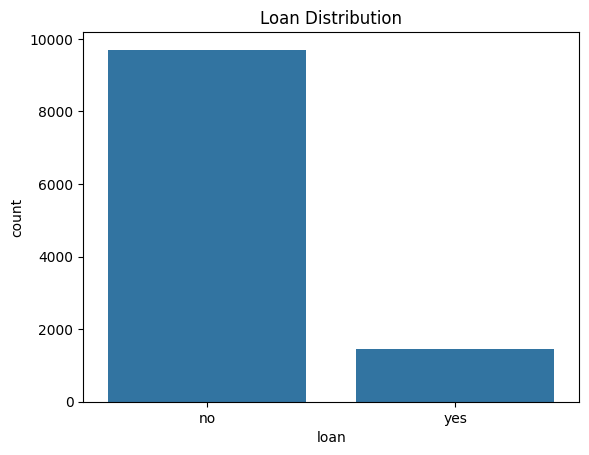

In [50]:
sns.countplot(x='loan', data=df)
plt.title('Loan Distribution')
plt.show()

In [51]:
# missing value
df.isnull().mean().sort_values(ascending=False)

,0
age,0.0
job,0.0
marital,0.0
education,0.0
default,0.0
balance,0.0
housing,0.0
loan,0.0
contact,0.0
day,0.0


In [52]:
num_cols = ['age','balance','day','duration','campaign','pdays','previous']

df[num_cols].describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


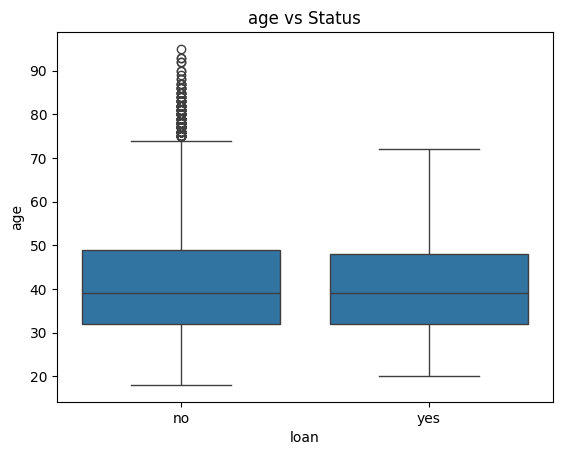

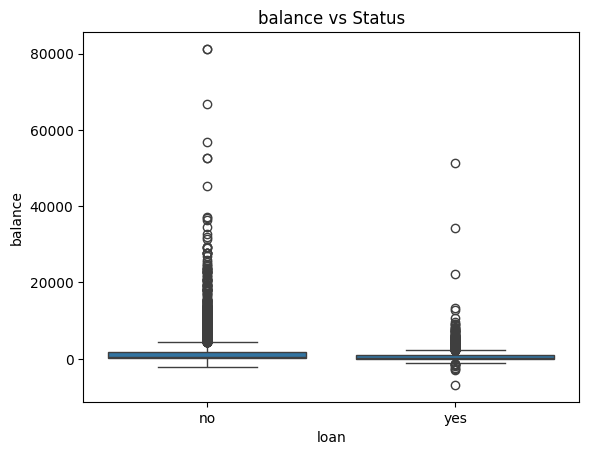

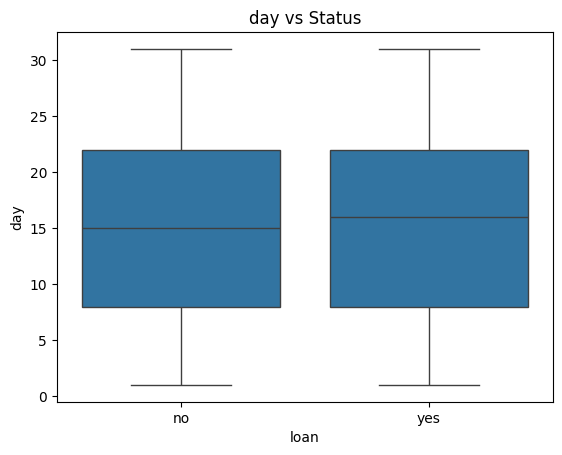

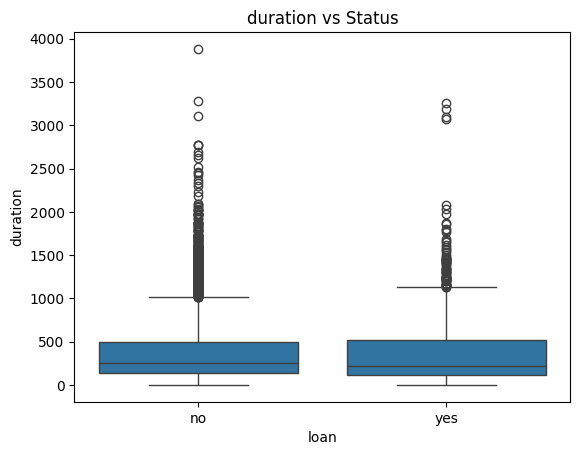

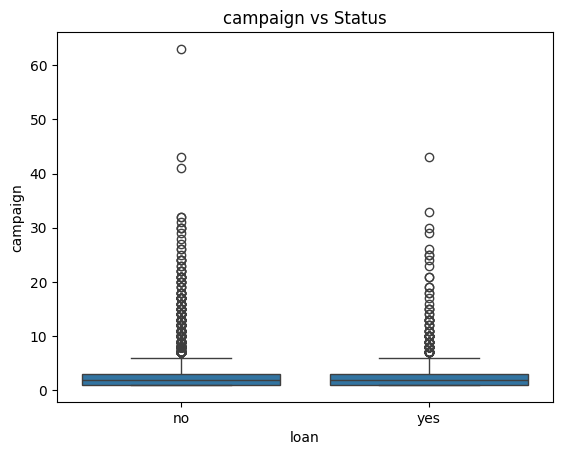

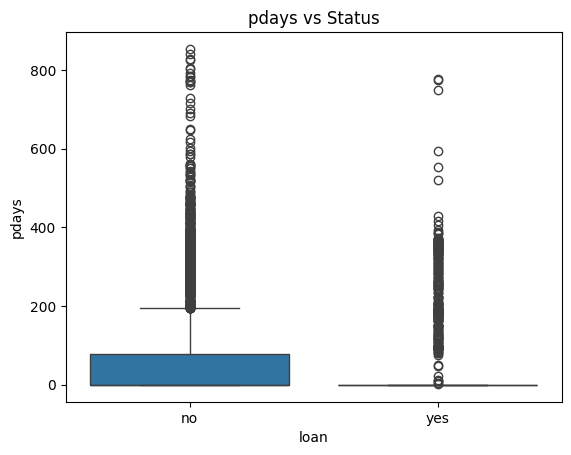

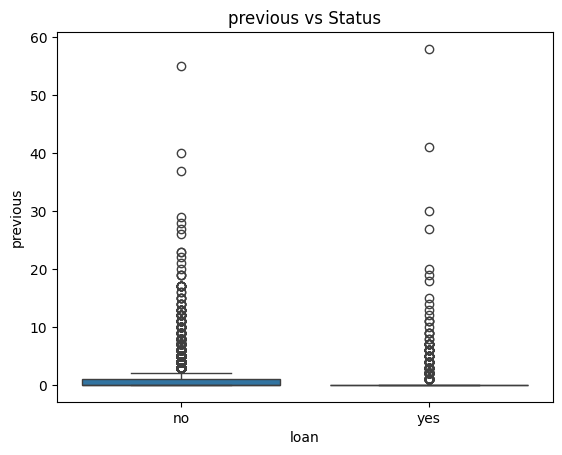

In [53]:
for col in num_cols:
    sns.boxplot(x='loan', y=col, data=df)
    plt.title(f'{col} vs Status')
    plt.show()

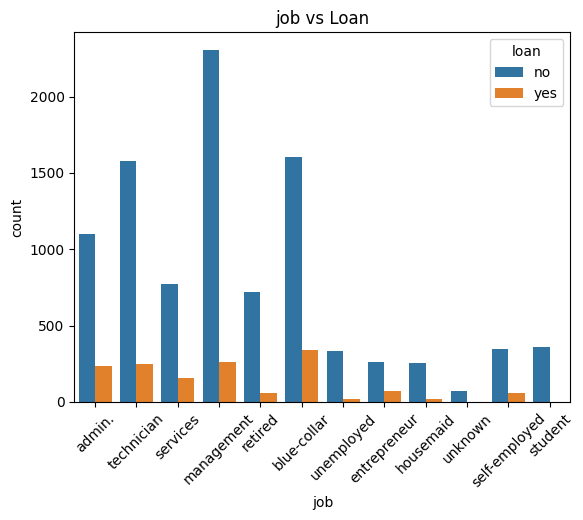

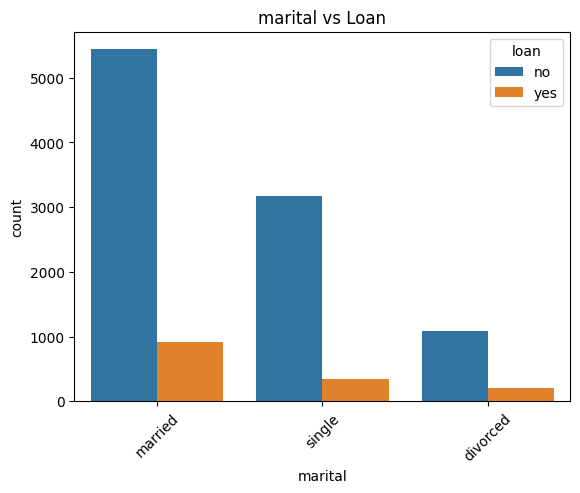

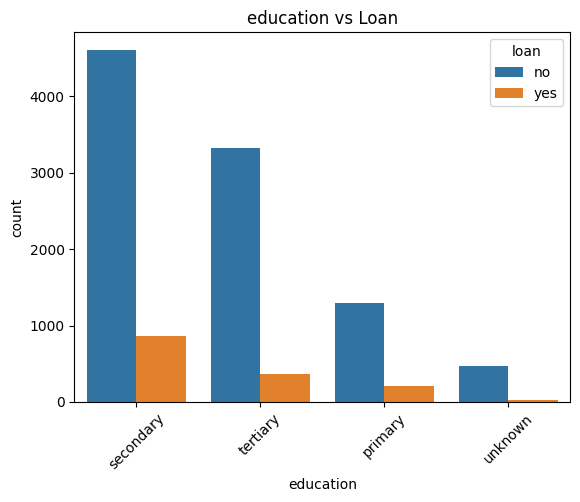

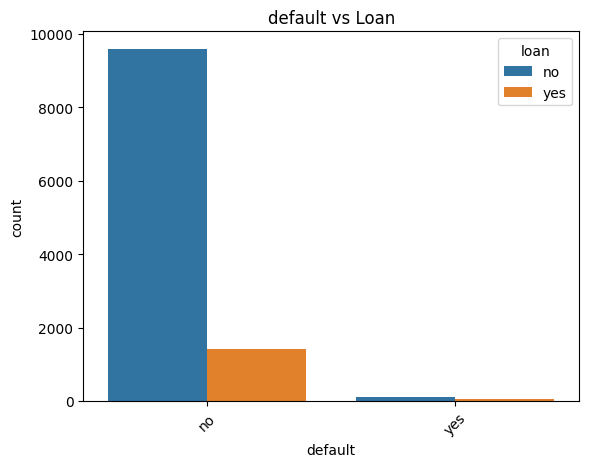

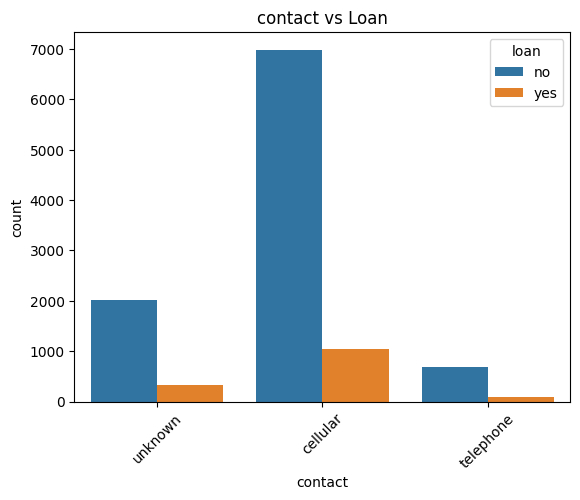

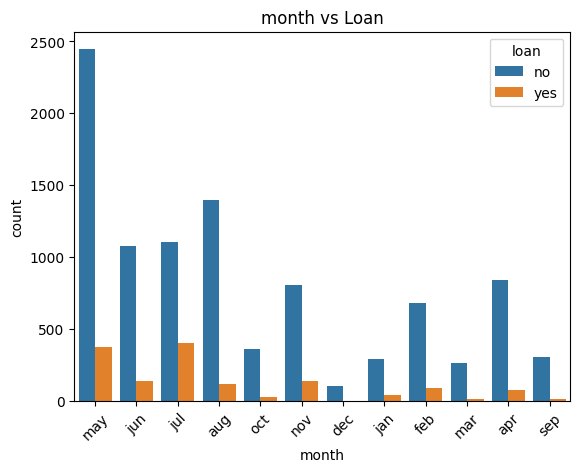

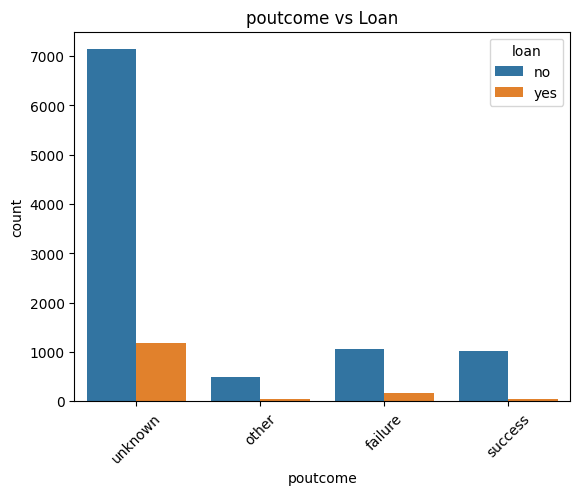

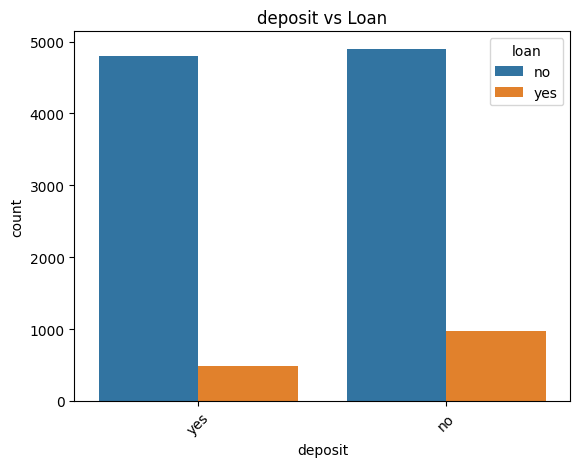

In [54]:
# categorical feature analysis
cat_cols = ['job','marital','education','default','contact','month','poutcome','deposit']

for col in cat_cols:
    sns.countplot(x=col, hue='loan', data=df)
    plt.xticks(rotation=45)
    plt.title(f'{col} vs Loan')
    plt.show()

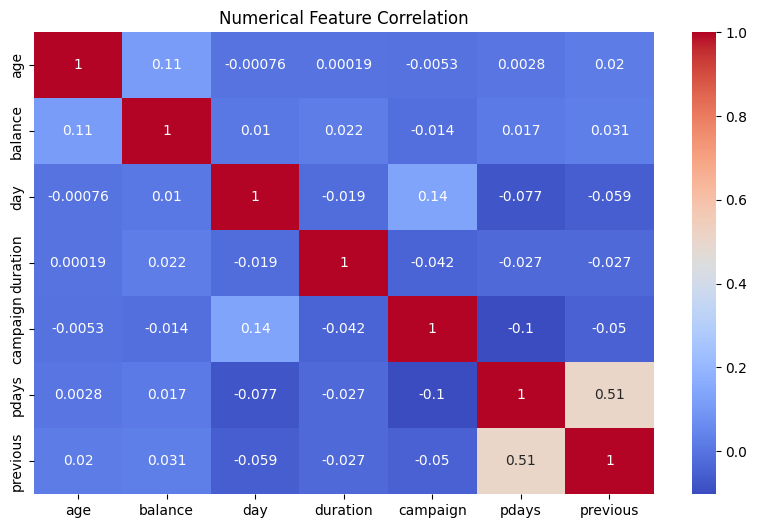

In [55]:
# correlation Analysis
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Numerical Feature Correlation')
plt.show()

In [56]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [57]:
target = 'loan'

num_cols = ['age','balance','day','duration','campaign','pdays','previous']

cat_cols = ['job','marital','education','default','contact','month','poutcome','deposit']

In [58]:
X = df[num_cols + cat_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [59]:
print(df.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='object')


In [60]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# definisi kolom
num_cols = ['age','balance','day','duration','campaign','pdays','previous']
cat_cols = ['job','marital','education','default','housing','loan','contact','month','poutcome']

# filter: hanya ambil kolom yang benar-benar ada di X_train
num_cols = [col for col in num_cols if col in X_train.columns]
cat_cols = [col for col in cat_cols if col in X_train.columns]

print("Kolom numerik dipakai:", num_cols)
print("Kolom kategorikal dipakai:", cat_cols)

# pipeline numerik
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# pipeline kategorikal
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# gabungkan
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

# transformasi data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


print("Shape train:", X_train_processed.shape)
print("Shape test:", X_test_processed.shape)

Kolom numerik dipakai: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Kolom kategorikal dipakai: ['job', 'marital', 'education', 'default', 'contact', 'month', 'poutcome']
Shape train: (8929, 47)
Shape test: (2233, 47)


In [61]:
# modeling & evaluation
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
from xgboost import XGBClassifier

# target sudah numerik
y_train_enc = y_train.map({'no':0, 'yes':1})
y_test_enc  = y_test.map({'no':0, 'yes':1})

# hitung rasio kelas untuk scale_pos_weight
scale_pos_weight = (y_train_enc == 0).sum() / (y_train_enc == 1).sum()

# model XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=42,
    use_label_encoder=False
)

# fit model
xgb_model.fit(X_train_processed, y_train_enc)

# prediksi
xgb_pred = xgb_model.predict(X_test_processed)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [13:42:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [63]:
test_pred_xgb = xgb_model.predict_proba(X_test_processed)[:,1]
print('XGBoost Test ROC-AUC:', roc_auc_score(y_test, test_pred_xgb))

XGBoost Test ROC-AUC: 0.7237760510399243


In [64]:
# thresholding
threshold = 0.4
y_pred = (test_pred_xgb >= threshold).astype(int)

# evaluasi
print(confusion_matrix(y_test_enc, y_pred))
print(classification_report(y_test_enc, y_pred))

[[1153  788]
 [  92  200]]
              precision    recall  f1-score   support

           0       0.93      0.59      0.72      1941
           1       0.20      0.68      0.31       292

    accuracy                           0.61      2233
   macro avg       0.56      0.64      0.52      2233
weighted avg       0.83      0.61      0.67      2233



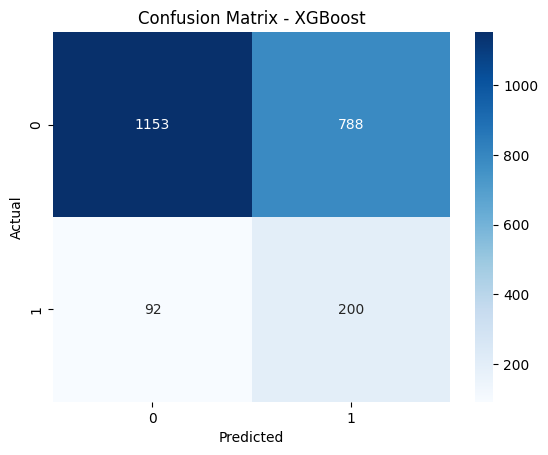

In [65]:
# buat confusion matrix
cm = confusion_matrix(y_test_enc, y_pred)

# plot heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [66]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 1. Pastikan target sudah numerik
y_train_enc = y_train.map({'no':0, 'yes':1})
y_test_enc  = y_test.map({'no':0, 'yes':1})

# 2. Definisikan model Naive Bayes
nb_model = GaussianNB()

# 3. Fit model ke data hasil preprocessing
nb_model.fit(X_train_processed, y_train_enc)

# 4. Prediksi
nb_pred = nb_model.predict(X_test_processed)

# 5. Evaluasi
print("Accuracy:", accuracy_score(y_test_enc, nb_pred))
print(confusion_matrix(y_test_enc, nb_pred))
print(classification_report(y_test_enc, nb_pred))

Accuracy: 0.48096730855351544
[[ 837 1104]
 [  55  237]]
              precision    recall  f1-score   support

           0       0.94      0.43      0.59      1941
           1       0.18      0.81      0.29       292

    accuracy                           0.48      2233
   macro avg       0.56      0.62      0.44      2233
weighted avg       0.84      0.48      0.55      2233



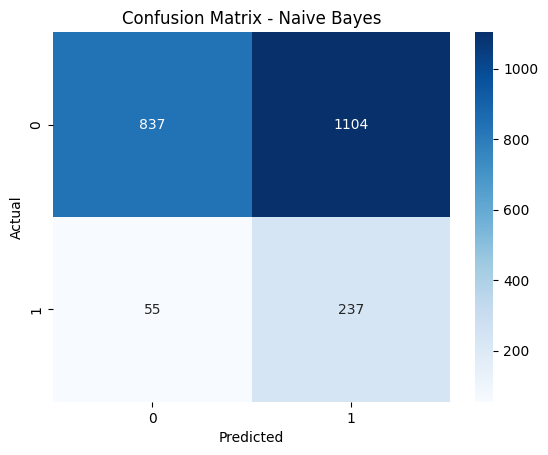

In [67]:
# buat confusion matrix untuk Naive Bayes
cm_nb = confusion_matrix(y_test_enc, nb_pred)

# plot heatmap
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [68]:
# --- XGBoost ---
y_pred_xgb = (test_pred_xgb >= 0.4).astype(int)
print("XGBoost")
print(confusion_matrix(y_test_enc, y_pred_xgb))
print(classification_report(y_test_enc, y_pred_xgb))

# --- Naive Bayes ---
nb_pred = nb_model.predict(X_test_processed)
print("Naive Bayes")
print(confusion_matrix(y_test_enc, nb_pred))
print(classification_report(y_test_enc, nb_pred))

XGBoost
[[1153  788]
 [  92  200]]
              precision    recall  f1-score   support

           0       0.93      0.59      0.72      1941
           1       0.20      0.68      0.31       292

    accuracy                           0.61      2233
   macro avg       0.56      0.64      0.52      2233
weighted avg       0.83      0.61      0.67      2233

Naive Bayes
[[ 837 1104]
 [  55  237]]
              precision    recall  f1-score   support

           0       0.94      0.43      0.59      1941
           1       0.18      0.81      0.29       292

    accuracy                           0.48      2233
   macro avg       0.56      0.62      0.44      2233
weighted avg       0.84      0.48      0.55      2233



In [69]:
import joblib

# simpan model XGBoost
joblib.dump(xgb_model, 'xgb_model.pkl')

# load kembali
xgb_model = joblib.load('xgb_model.pkl')

In [70]:
# ubah target ke numerik
y_train_enc = y_train.map({'no':0, 'yes':1})
y_test_enc  = y_test.map({'no':0, 'yes':1})

# pipeline lengkap dengan model XGBoost
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import joblib
from google.colab import files

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss'
    ))
])

# latih model dengan target yang sudah di-encode
pipeline.fit(X_train, y_train_enc)

# simpan pipeline
joblib.dump(pipeline, 'bank_marketing_pipeline_xgb.pkl')

# download ke komputer
files.download('bank_marketing_pipeline_xgb.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

EXPLAINABILITY & CREDIT RISK SCORING

LOAD TRAINED PIPELINE

In [71]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

# Load trained pipeline (preprocessing + model)
from google.colab import files
uploaded = files.upload()
pipeline = joblib.load('bank_marketing_pipeline_xgb.pkl')

Saving bank_marketing_pipeline_xgb (1).pkl to bank_marketing_pipeline_xgb (1) (1).pkl


PREPARE DATA FOR EXPLAINABILITY

In [72]:
# Tentukan target
target = 'deposit'

# Pisahkan fitur dan target
X = df.drop(columns=[target])
y = df[target]

# Ambil subset data untuk SHAP agar komputasi lebih cepat
X_sample = X.sample(n=min(1000, len(X)), random_state=42)

SHAP EXPLAINER SETUP

In [73]:
import shap

# Ambil model dan preprocessor dari pipeline
model = pipeline.named_steps['model']
preprocessor = pipeline.named_steps['preprocessor']

# Transform data sampel
X_sample_processed = preprocessor.transform(X_sample)

# Buat SHAP explainer
explainer = shap.TreeExplainer(model)

# Hitung SHAP values
shap_values = explainer(X_sample_processed)

GLOBAL EXPLAINABILITY

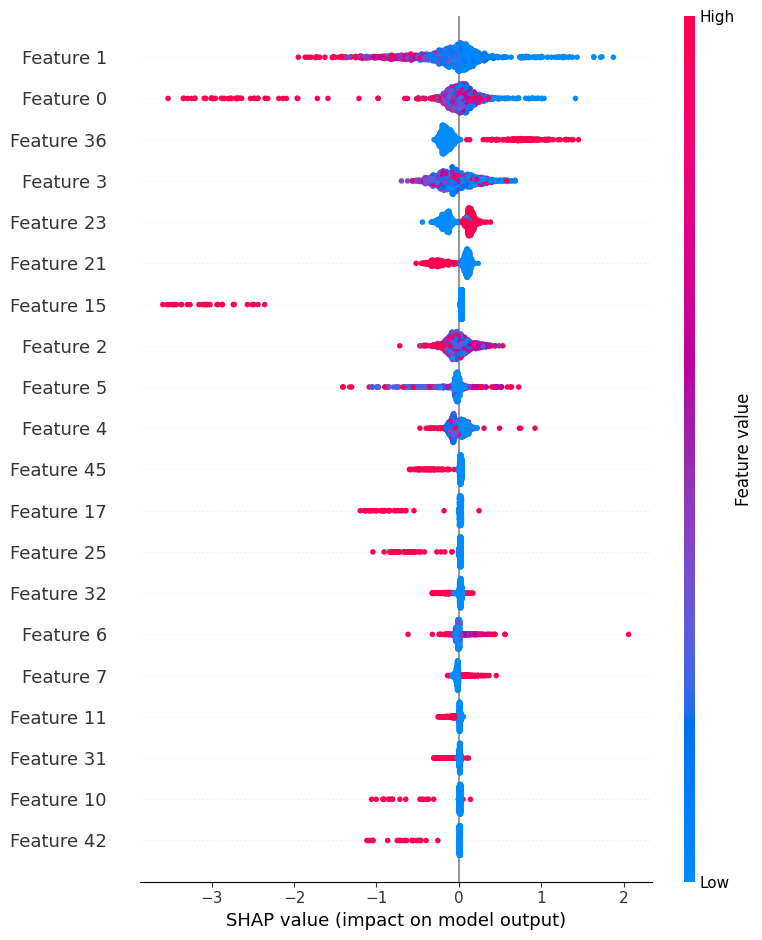

In [74]:
# Global Explainability
shap.summary_plot(shap_values, X_sample_processed)

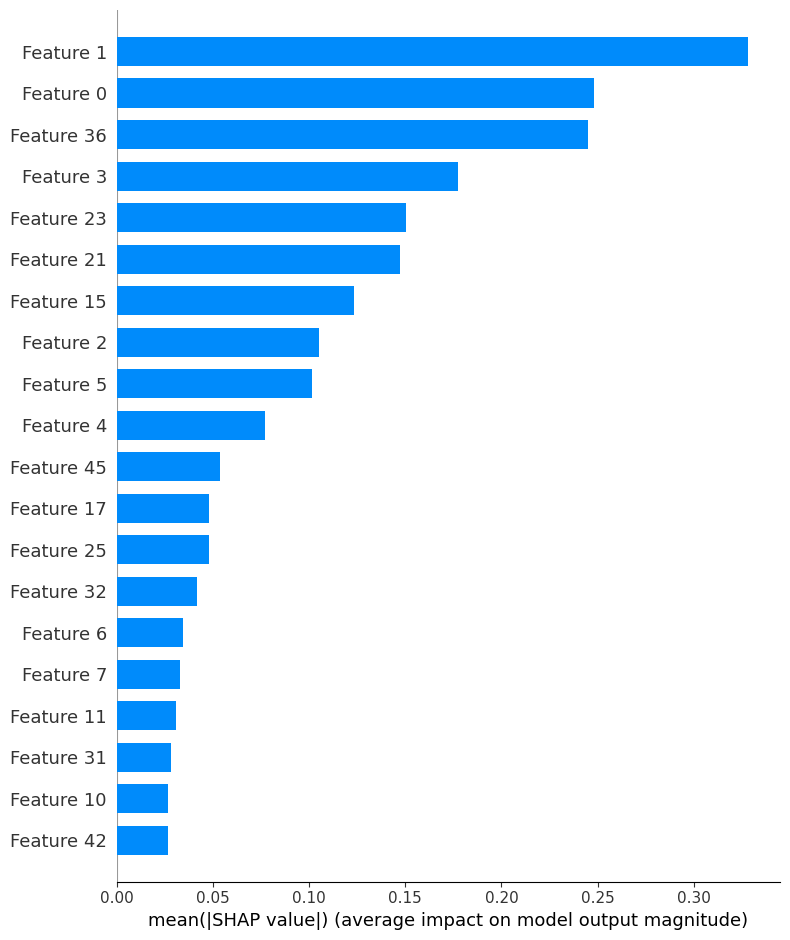

In [75]:
shap.summary_plot(shap_values, X_sample_processed, plot_type='bar')

LOCAL EXPLAINABILITY (SINGLE PREDICTION)

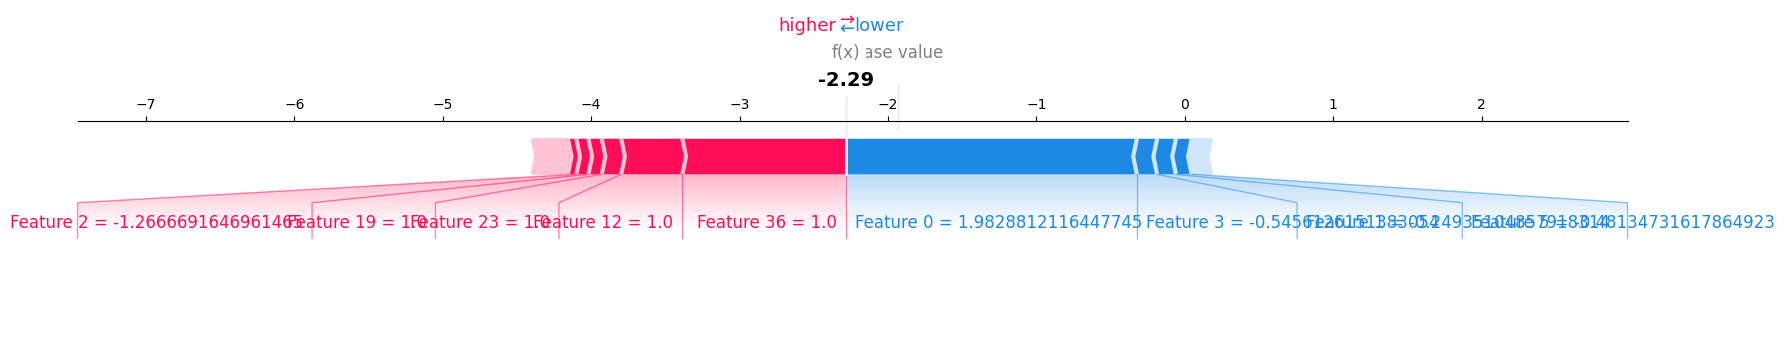

In [76]:
# Select a single observation
idx = 0
X_single = X_sample.iloc[[idx]]
X_single_processed = preprocessor.transform(X_single)

shap_value_single = explainer.shap_values(X_single_processed)

shap.force_plot(
    explainer.expected_value,
    shap_value_single,
    X_single_processed,
    matplotlib=True
)

CREDIT RISK SCORE GENERATION

In [77]:
def credit_risk_score(prob_default):
    return int(100 - prob_default * 100)

def risk_category(score):
    if score >= 80:
        return 'Low Risk'
    elif score >= 60:
        return 'Medium Risk'
    else:
        return 'High Risk'

In [78]:
# Fungsi untuk mengubah probabilitas menjadi skor 0-100
def deposit_score(prob):
    return round(prob * 100, 2)

# Fungsi untuk mengelompokkan skor
def deposit_category(score):
    if score >= 80:
        return 'Very Likely'
    elif score >= 60:
        return 'Likely'
    elif score >= 40:
        return 'Moderate'
    else:
        return 'Unlikely'

In [79]:
# Prediksi probabilitas nasabah melakukan deposit (kelas 'yes')
probs = pipeline.predict_proba(X_sample)[:, 1]

# Buat dataframe hasil
results = X_sample.copy()
results['prob_deposit'] = probs
results['deposit_score'] = results['prob_deposit'].apply(deposit_score)
results['deposit_category'] = results['deposit_score'].apply(deposit_category)

results.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,prob_deposit,deposit_score,deposit_category
5527,65,retired,divorced,secondary,no,744,no,no,cellular,5,jul,182,1,-1,0,unknown,0.092294,9.23,Unlikely
4541,38,blue-collar,married,secondary,no,1627,no,no,unknown,16,jun,1323,9,-1,0,unknown,0.114424,11.44,Unlikely
1964,35,blue-collar,single,secondary,no,4963,yes,no,cellular,14,may,456,1,300,1,failure,0.032242,3.22,Unlikely
5007,47,blue-collar,married,secondary,no,8229,no,no,cellular,8,aug,784,2,-1,0,unknown,0.043631,4.36,Unlikely
8928,35,technician,married,tertiary,no,1473,yes,no,unknown,12,may,84,3,-1,0,unknown,0.125403,12.54,Unlikely


FINAL TRAINING & DEPLOYMENT PIPELINE

In [80]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
import joblib

In [81]:
target = 'deposit'

num_cols = [
    'age',
    'balance',
    'day',
    'duration',
    'campaign',
    'pdays',
    'previous'
]

cat_cols = [
    'job',
    'marital',
    'education',
    'default',
    'housing',
    'loan',
    'contact',
    'month',
    'poutcome'
]

X = df[num_cols + cat_cols]
y = df[target]

In [82]:
print(X.columns.tolist())
print(y.head())

['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
0    yes
1    yes
2    yes
3    yes
4    yes
Name: deposit, dtype: object


In [83]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [84]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [85]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

# Encode target: no=0, yes=1
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Hitung scale_pos_weight
scale_pos_weight = (y_train_enc == 0).sum() / (y_train_enc == 1).sum()

# Definisikan model
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='auc',
    random_state=42
)

# Buat pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb_model)
])

# Train model
pipeline.fit(X_train, y_train_enc)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['age', 'balance', 'day',
                                                   'duration', 'campaign',
                                                   'pdays', 'previous']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['j...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [86]:
train_auc = roc_auc_score(y_train, pipeline.predict_proba(X_train)[:,1])
test_auc = roc_auc_score(y_test, pipeline.predict_proba(X_test)[:,1])

train_auc, test_auc

(np.float64(0.9681870539558866), np.float64(0.9310067168081084))

In [87]:
joblib.dump(pipeline, 'bank_marketing_pipeline_xgb.pkl')

['bank_marketing_pipeline_xgb.pkl']

Jalanin Streamlit

In [88]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from datetime import datetime

# ==================================================
# PAGE CONFIG
# ==================================================
st.set_page_config(
    page_title="Bank Deposit Prediction Dashboard",
    page_icon="🏦",
    layout="wide"
)

# ==================================================
# LOAD DATASET
# ==================================================
@st.cache_data
def load_data():
    return pd.read_csv("bank (data final project).csv")

df = load_data()

# ==================================================
# LOAD MODEL
# ==================================================
@st.cache_resource
def load_pipeline():
    return joblib.load("bank_marketing_pipeline_xgb.pkl")

pipeline = load_pipeline()

# ==================================================
# SESSION STATE
# ==================================================
if "history" not in st.session_state:
    st.session_state.history = []

# ==================================================
# HEADER
# ==================================================
st.title("🏦 Bank Deposit Prediction Dashboard")
st.markdown(
    "Predict whether a customer will subscribe to a term deposit using XGBoost."
)

# ==================================================
# SIDEBAR INPUT
# ==================================================
st.sidebar.header("📋 Customer Information")

with st.sidebar.expander("👤 Customer Profile", expanded=True):

    age = st.number_input("Age", 18, 100, 40)

    job = st.selectbox(
        "Job",
        [
            "admin.", "blue-collar", "entrepreneur",
            "housemaid", "management", "retired",
            "self-employed", "services", "student",
            "technician", "unemployed", "unknown"
        ]
    )

    marital = st.selectbox(
        "Marital Status",
        ["married", "single", "divorced"]
    )

    education = st.selectbox(
        "Education",
        ["primary", "secondary", "tertiary", "unknown"]
    )

    default = st.selectbox(
        "Credit Default",
        ["no", "yes"]
    )

with st.sidebar.expander("💰 Financial Information", expanded=True):

    balance = st.number_input(
        "Account Balance (€)",
        value=1000
    )

    housing = st.selectbox(
        "Housing Loan",
        ["no", "yes"]
    )

    loan = st.selectbox(
        "Personal Loan",
        ["no", "yes"]
    )

with st.sidebar.expander("📞 Campaign Information", expanded=True):

    contact = st.selectbox(
        "Contact Type",
        ["cellular", "telephone", "unknown"]
    )

    day = st.slider(
        "Last Contact Day",
        1, 31, 15
    )

    month = st.selectbox(
        "Month",
        [
            "jan","feb","mar","apr","may","jun",
            "jul","aug","sep","oct","nov","dec"
        ]
    )

    duration = st.number_input(
        "Call Duration (seconds)",
        min_value=0,
        value=300
    )

    campaign = st.number_input(
        "Number of Contacts",
        min_value=1,
        value=1
    )

    pdays = st.number_input(
        "Days Since Previous Contact",
        value=-1
    )

    previous = st.number_input(
        "Previous Contacts",
        min_value=0,
        value=0
    )

    poutcome = st.selectbox(
        "Previous Campaign Outcome",
        ["unknown", "failure", "success", "other"]
    )

predict_button = st.sidebar.button(
    "🔍 Predict Deposit Subscription",
    type="primary"
)

# ==================================================
# TABS
# ==================================================
tab_overview, tab_prediction, tab_analytics, tab_explain, tab_history = st.tabs([
    "📌 Overview",
    "🔍 Prediction",
    "📊 Analytics",
    "🧠 Explainability",
    "📜 History"
])

# ==================================================
# PREDICTION
# ==================================================
if predict_button:

    input_df = pd.DataFrame([{
        "age": age,
        "job": job,
        "marital": marital,
        "education": education,
        "default": default,
        "balance": balance,
        "housing": housing,
        "loan": loan,
        "contact": contact,
        "day": day,
        "month": month,
        "duration": duration,
        "campaign": campaign,
        "pdays": pdays,
        "previous": previous,
        "poutcome": poutcome
    }])

    prob = pipeline.predict_proba(input_df)[0][1]

    score = int(prob * 100)

    if score >= 80:
        category = "Very Likely"
        color = "🟢"
    elif score >= 60:
        category = "Likely"
        color = "🟡"
    else:
        category = "Unlikely"
        color = "🔴"

    st.session_state.last_prediction = {
        "prob": prob,
        "score": score,
        "category": category,
        "color": color,
        "input_df": input_df
    }

    st.session_state.history.append({
        "Timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "Probability": f"{prob:.1%}",
        "Score": score,
        "Category": category
    })

# ==================================================
# OVERVIEW
# ==================================================
with tab_overview:

    total_customers = len(df)
    total_features = len(df.columns) - 1

    yes_count = (df["deposit"] == "yes").sum()
    no_count = (df["deposit"] == "no").sum()

    st.subheader("Dataset Overview")

    c1, c2, c3, c4 = st.columns(4)

    c1.metric("Customers", f"{total_customers:,}")
    c2.metric("Features", total_features)
    c3.metric("Subscribe Yes", yes_count)
    c4.metric("Subscribe No", no_count)

    st.divider()

    st.subheader("Deposit Distribution")

    fig, ax = plt.subplots()

    ax.pie(
        df["deposit"].value_counts(),
        labels=df["deposit"].value_counts().index,
        autopct="%1.1f%%"
    )

    st.pyplot(fig)

# ==================================================
# PREDICTION TAB
# ==================================================
with tab_prediction:

    if "last_prediction" in st.session_state:

        pred = st.session_state.last_prediction

        c1, c2, c3 = st.columns(3)

        c1.metric(
            "Probability",
            f"{pred['prob']:.1%}"
        )

        c2.metric(
            "Score",
            f"{pred['score']}/100"
        )

        c3.metric(
            "Category",
            f"{pred['color']} {pred['category']}"
        )

        st.progress(pred["score"]/100)

        st.subheader("Recommendation")

        if pred["score"] >= 80:
            st.success("Recommended for immediate marketing follow-up.")

        elif pred["score"] >= 60:
            st.warning("Potential customer. Additional follow-up suggested.")

        else:
            st.error("Low priority customer.")

        st.subheader("Customer Input Summary")

        st.dataframe(
            pred["input_df"],
            hide_index=True
        )

    else:
        st.info("Input customer data and click Predict.")

# ==================================================
# ANALYTICS
# ==================================================
with tab_analytics:

    st.subheader("Customer Demographics Analysis")

    # ----------------------------------------------
    # JOB DISTRIBUTION
    # ----------------------------------------------
    col1, col2 = st.columns(2)

    with col1:

        st.markdown("### Job Distribution")

        job_counts = df["job"].value_counts()

        fig, ax = plt.subplots(figsize=(6,4))

        ax.bar(
            job_counts.index,
            job_counts.values
        )

        plt.xticks(rotation=45)

        st.pyplot(fig)

    # ----------------------------------------------
    # EDUCATION DISTRIBUTION
    # ----------------------------------------------
    with col2:

        st.markdown("### Education Distribution")

        edu_counts = df["education"].value_counts()

        fig, ax = plt.subplots(figsize=(5,5))

        ax.pie(
            edu_counts,
            labels=edu_counts.index,
            autopct="%1.1f%%"
        )

        st.pyplot(fig)

    st.divider()

    # ----------------------------------------------
    # MARITAL STATUS
    # ----------------------------------------------
    col3, col4 = st.columns(2)

    with col3:

        st.markdown("### Marital Status")

        marital_counts = df["marital"].value_counts()

        fig, ax = plt.subplots(figsize=(5,4))

        ax.barh(
            marital_counts.index,
            marital_counts.values
        )

        st.pyplot(fig)

    # ----------------------------------------------
    # CONTACT TYPE
    # ----------------------------------------------
    with col4:

        st.markdown("### Contact Type")

        contact_counts = df["contact"].value_counts()

        fig, ax = plt.subplots(figsize=(5,4))

        ax.pie(
            contact_counts,
            labels=contact_counts.index,
            autopct="%1.1f%%"
        )

        st.pyplot(fig)

    st.divider()

    # ----------------------------------------------
    # BALANCE DISTRIBUTION
    # ----------------------------------------------
    st.markdown("### Balance Distribution")

    fig, ax = plt.subplots(figsize=(8,4))

    ax.hist(
        df["balance"],
        bins=30
    )

    ax.set_xlabel("Balance (€)")
    ax.set_ylabel("Frequency")
    ax.set_title("Customer Account Balance Distribution")

    st.pyplot(fig)

    st.divider()

    # ----------------------------------------------
    # MONTHLY CONTACT TREND
    # ----------------------------------------------
    st.markdown("### Contact Month Trend")

    month_order = [
        "jan","feb","mar","apr","may","jun",
        "jul","aug","sep","oct","nov","dec"
    ]

    month_counts = (
        df["month"]
        .value_counts()
        .reindex(month_order)
    )

    fig, ax = plt.subplots(figsize=(8,4))

    ax.plot(
        month_counts.index,
        month_counts.values,
        marker="o"
    )

    ax.set_ylabel("Number of Contacts")
    ax.set_xlabel("Month")

    st.pyplot(fig)

    st.divider()

    # ----------------------------------------------
    # PREVIOUS CAMPAIGN OUTCOME
    # ----------------------------------------------
    st.markdown("### Previous Campaign Outcome")

    poutcome_counts = df["poutcome"].value_counts()

    fig, ax = plt.subplots(figsize=(6,4))

    ax.bar(
        poutcome_counts.index,
        poutcome_counts.values
    )

    st.pyplot(fig)

    st.divider()

    # ----------------------------------------------
    # DEPOSIT BY EDUCATION
    # ----------------------------------------------
    st.markdown("### Deposit Subscription by Education")

    deposit_edu = pd.crosstab(
        df["education"],
        df["deposit"]
    )

    st.bar_chart(deposit_edu)

# ==================================================
# EXPLAINABILITY
# ==================================================
with tab_explain:

    st.subheader("Feature Importance")

    try:

        model = pipeline.named_steps["model"]

        preprocessor = pipeline.named_steps["preprocessor"]

        importance_df = pd.DataFrame({
            "Feature": preprocessor.get_feature_names_out(),
            "Importance": model.feature_importances_
        })

        importance_df = importance_df.sort_values(
            "Importance",
            ascending=False
        )

        st.bar_chart(
            importance_df.head(10).set_index("Feature")
        )

        st.dataframe(
            importance_df.head(10),
            hide_index=True
        )

    except:
        st.warning("Feature importance unavailable.")

# ==================================================
# HISTORY
# ==================================================
with tab_history:

    if st.session_state.history:

        history_df = pd.DataFrame(
            st.session_state.history
        )

        c1, c2 = st.columns(2)

        c1.metric(
            "Total Predictions",
            len(history_df)
        )

        c2.metric(
            "Average Score",
            round(history_df["Score"].mean(), 1)
        )

        st.dataframe(
            history_df,
            hide_index=True
        )

    else:
        st.info("No predictions yet.")

Overwriting app.py


In [89]:
# Install Library
!pip install streamlit pyngrok -q

from pyngrok import ngrok
import subprocess
import threading
import time
import math
from IPython.display import display, HTML

In [90]:
# Ensure all ngrok tunnels from previous runs are killed before starting a new one
ngrok.kill()

# Token NGROK
NGROK_TOKEN = "3EEzmTsIJs5qMI9CfsM8J4pfEGL_3ZYrfs6wqhhbZfKeBpTDe"

print ("Menjalankan Streamlit")

# SET TOKEN
ngrok.set_auth_token(NGROK_TOKEN)

# Jalankan Streamlit di Background
def run():
  subprocess.Popen(["streamlit", "run", "app.py", "--server.port",
                    "8501", "--server.address", "0.0.0.0"])

threading.Thread(target=run).start()
time.sleep(8)

# Buat Tunnel NGROK
tunnel = ngrok.connect(8501, "http")
url = tunnel.public_url

print(f"\nBERHASIL! Buka URL ini: {url}\n")

# Tampilkan LINK
display(HTML(f'<h2><a href="{url}" target="_blank"> Klik untuk Membuka Dashboard</a></h2>'))
print("Dashboard Berjalan. Tekan Stop Runtime untuk berhenti")

Menjalankan Streamlit

BERHASIL! Buka URL ini: https://nemesis-flatware-decimal.ngrok-free.dev



Dashboard Berjalan. Tekan Stop Runtime untuk berhenti
